alpha

In [58]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.1,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/extentions_all_pretrain_block_123/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")

 
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--mode=finetuning--n_samples={n_sample}--alpha_load={alpha}"
            )
    
            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")


✅ Loaded Seed 0, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 3, Al

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err

def plot_merged_run_and_csv(
    run_data,
    metric_name,
    type_val,
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Calculate inverse alphas and update LogNorm
    inv_alphas = [1.0 / a for a in alphas]
    cmap = plt.colormaps["viridis"]
    # We now normalize based on the range of 1/alpha
    norm = LogNorm(vmin=min(inv_alphas), vmax=max(inv_alphas))

    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    # --------- RUN_DATA PLOT ----------
    for alpha in alphas:
        inv_alpha = 1.0 / alpha # Define the transformed value
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y

                    if y <= 0: continue
                    vals.append(y)

                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            continue

        # 2. Use inv_alpha for the label and the color mapping
        ax.errorbar(
            samples,
            means,
            yerr=errs,
            label=f"α = {inv_alpha:.2f}", 
            color=cmap(norm(inv_alpha)), 
            marker="o",
            linestyle="-",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Sample Size", fontsize=11)
    # 3. Updated Y-label logic if needed, but keeping your request for 1-Acc
    ax.set_ylabel("1 − Accuracy" if do_one_minus_run else metric_name, fontsize=11)

    ax.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    # 4. Optional: Updated Colorbar for 1/alpha
     # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
     # sm.set_array([])
     # cbar = fig.colorbar(sm, ax=ax, pad=0.02)
     # cbar.set_label(r"$1/\alpha$", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

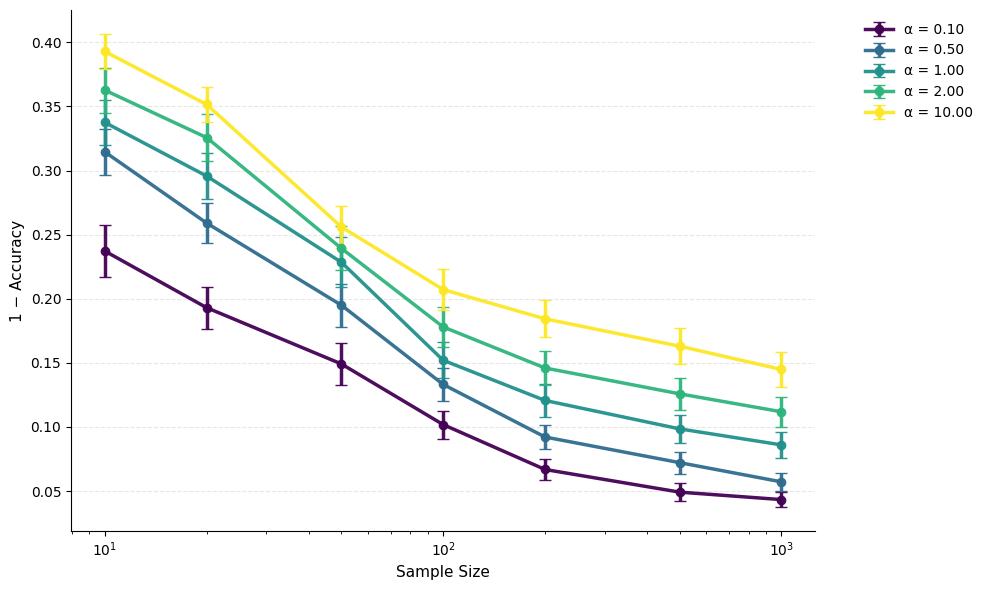

In [62]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [10,2,1.0,0.5,0.1],

    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

Gamma

In [55]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.1,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/extentions_all_pretrain_fc/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")

 
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--mode=finetuning--n_samples={n_sample}--finetune_scaling_last={alpha}"
            )
            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

✅ Loaded Seed 0, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 3, Al

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err


def plot_merged_run_and_csv(
    run_data,
    metric_name,
    type_val,
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # ---- colormap with LOG-scaled alpha ----
    cmap = plt.colormaps["viridis"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("viridis")
    norm = LogNorm(vmin=min(alphas), vmax=max(alphas))

    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    # --------- RUN_DATA PLOT ----------
    for alpha in alphas:
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y

                    # protect log plots
                    if y <= 0:
                        continue

                    vals.append(y)

                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            print(f"[WARN] α={alpha} produced all-NaN. Skipping.")
            continue

        ax.errorbar(
            samples,
            means,
            yerr=errs,
            label=f"gamma={alpha}",
            color=cmap(norm(alpha)),
            marker="o",
            linestyle="-",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("1 − Accuracy", fontsize=11)

    ax.legend(frameon=False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    # --------- Log-scaled colorbar ----------
    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    # cbar.set_label("c_pt (alpha)", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

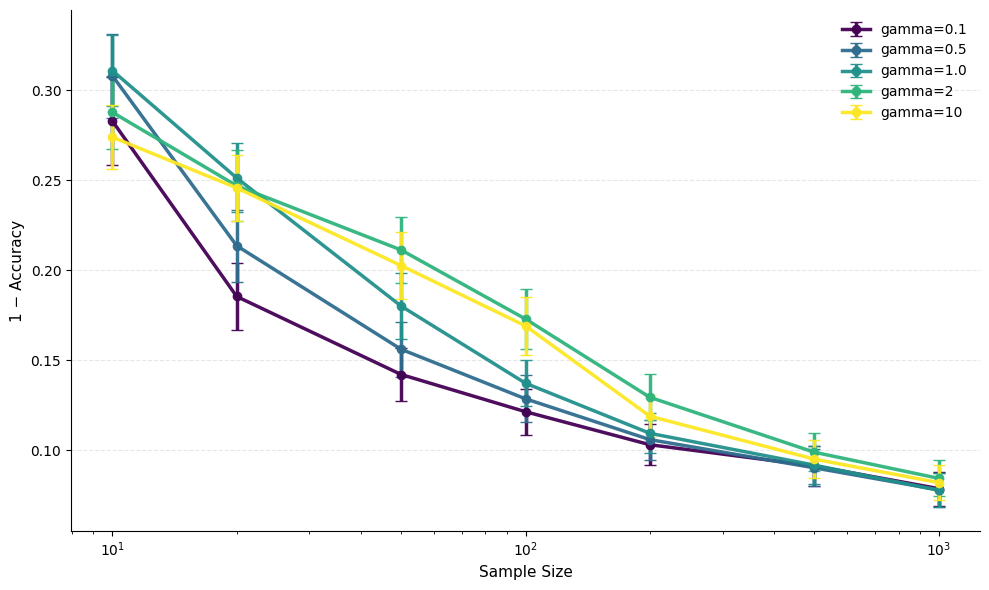

In [57]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,10],
    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

In [65]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
seeds = list(range(20))
n_samples= [10, 50, 100, 200, 500, 1000]
alphas = [0.1,0.5,1.0,2,5,10]
base_path = Path("/nfs/nhome/live/cdomine/old_sam/multi-task/data/cifar/ensd_fc/")

# Nested dictionary for structured access
run_data = {
    "df": {a: {s: [] for s in n_samples} for a in alphas},
}
all_long = []  # Stores long-format rows for every run
all_wide = []  # Stores wide-format per run

# --- Data Loading Loop ---
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples:
            # Construct folder name based on experimental parameters
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--finetune_scaling_last={alpha}"
            )
           
            dir_path = base_path / folder_name
            csv_path = dir_path / "df.csv"

            if not csv_path.exists():
                print(f'not downloaded {csv_path}')
                continue

            # --- Read CSV (long format: value, variable, layer) ---
            df = pd.read_csv(csv_path)

            # Cleanup: drop stray index column if present
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])

            # Ensure expected columns exist
            expected = {"value", "variable", "layer"}
            missing = expected - set(df.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing columns: {missing}")

            # Enforce data types
            df["value"] = df["value"].astype(float)
            df["layer"] = df["layer"].astype(int)

            # Add metadata for filtering/grouping
            df["alpha"] = float(alpha)
            df["seed"] = int(seed)
            df["n_samples"] = int(n_sample)

            # Save in nested structure and global list
            run_data["df"][alpha][n_sample].append(df)
            all_long.append(df)
            # --- Optional: build wide-format for this run ---
            # Transforms: Layer | Variable_A_Value | Variable_B_Value
            df_wide = (
                df.pivot(index="layer", columns="variable", values="value")
                  .reset_index()
            )
            df_wide["alpha"] = float(alpha)
            df_wide["seed"] = int(seed)
            df_wide["n_samples"] = int(n_sample)
            all_wide.append(df_wide)

# --- Final Aggregation ---
if all_long:
    df_all_long = pd.concat(all_long, ignore_index=True)
else:
    df_all_long = pd.DataFrame()

if all_wide:
    df_all_wide = pd.concat(all_wide, ignore_index=True)
else:
    df_all_wide = pd.DataFrame()
print("All long-format rows:", df_all_long.shape)
print("All wide-format rows:", df_all_wide.shape)

All long-format rows: (20160, 6)
All wide-format rows: (5040, 8)


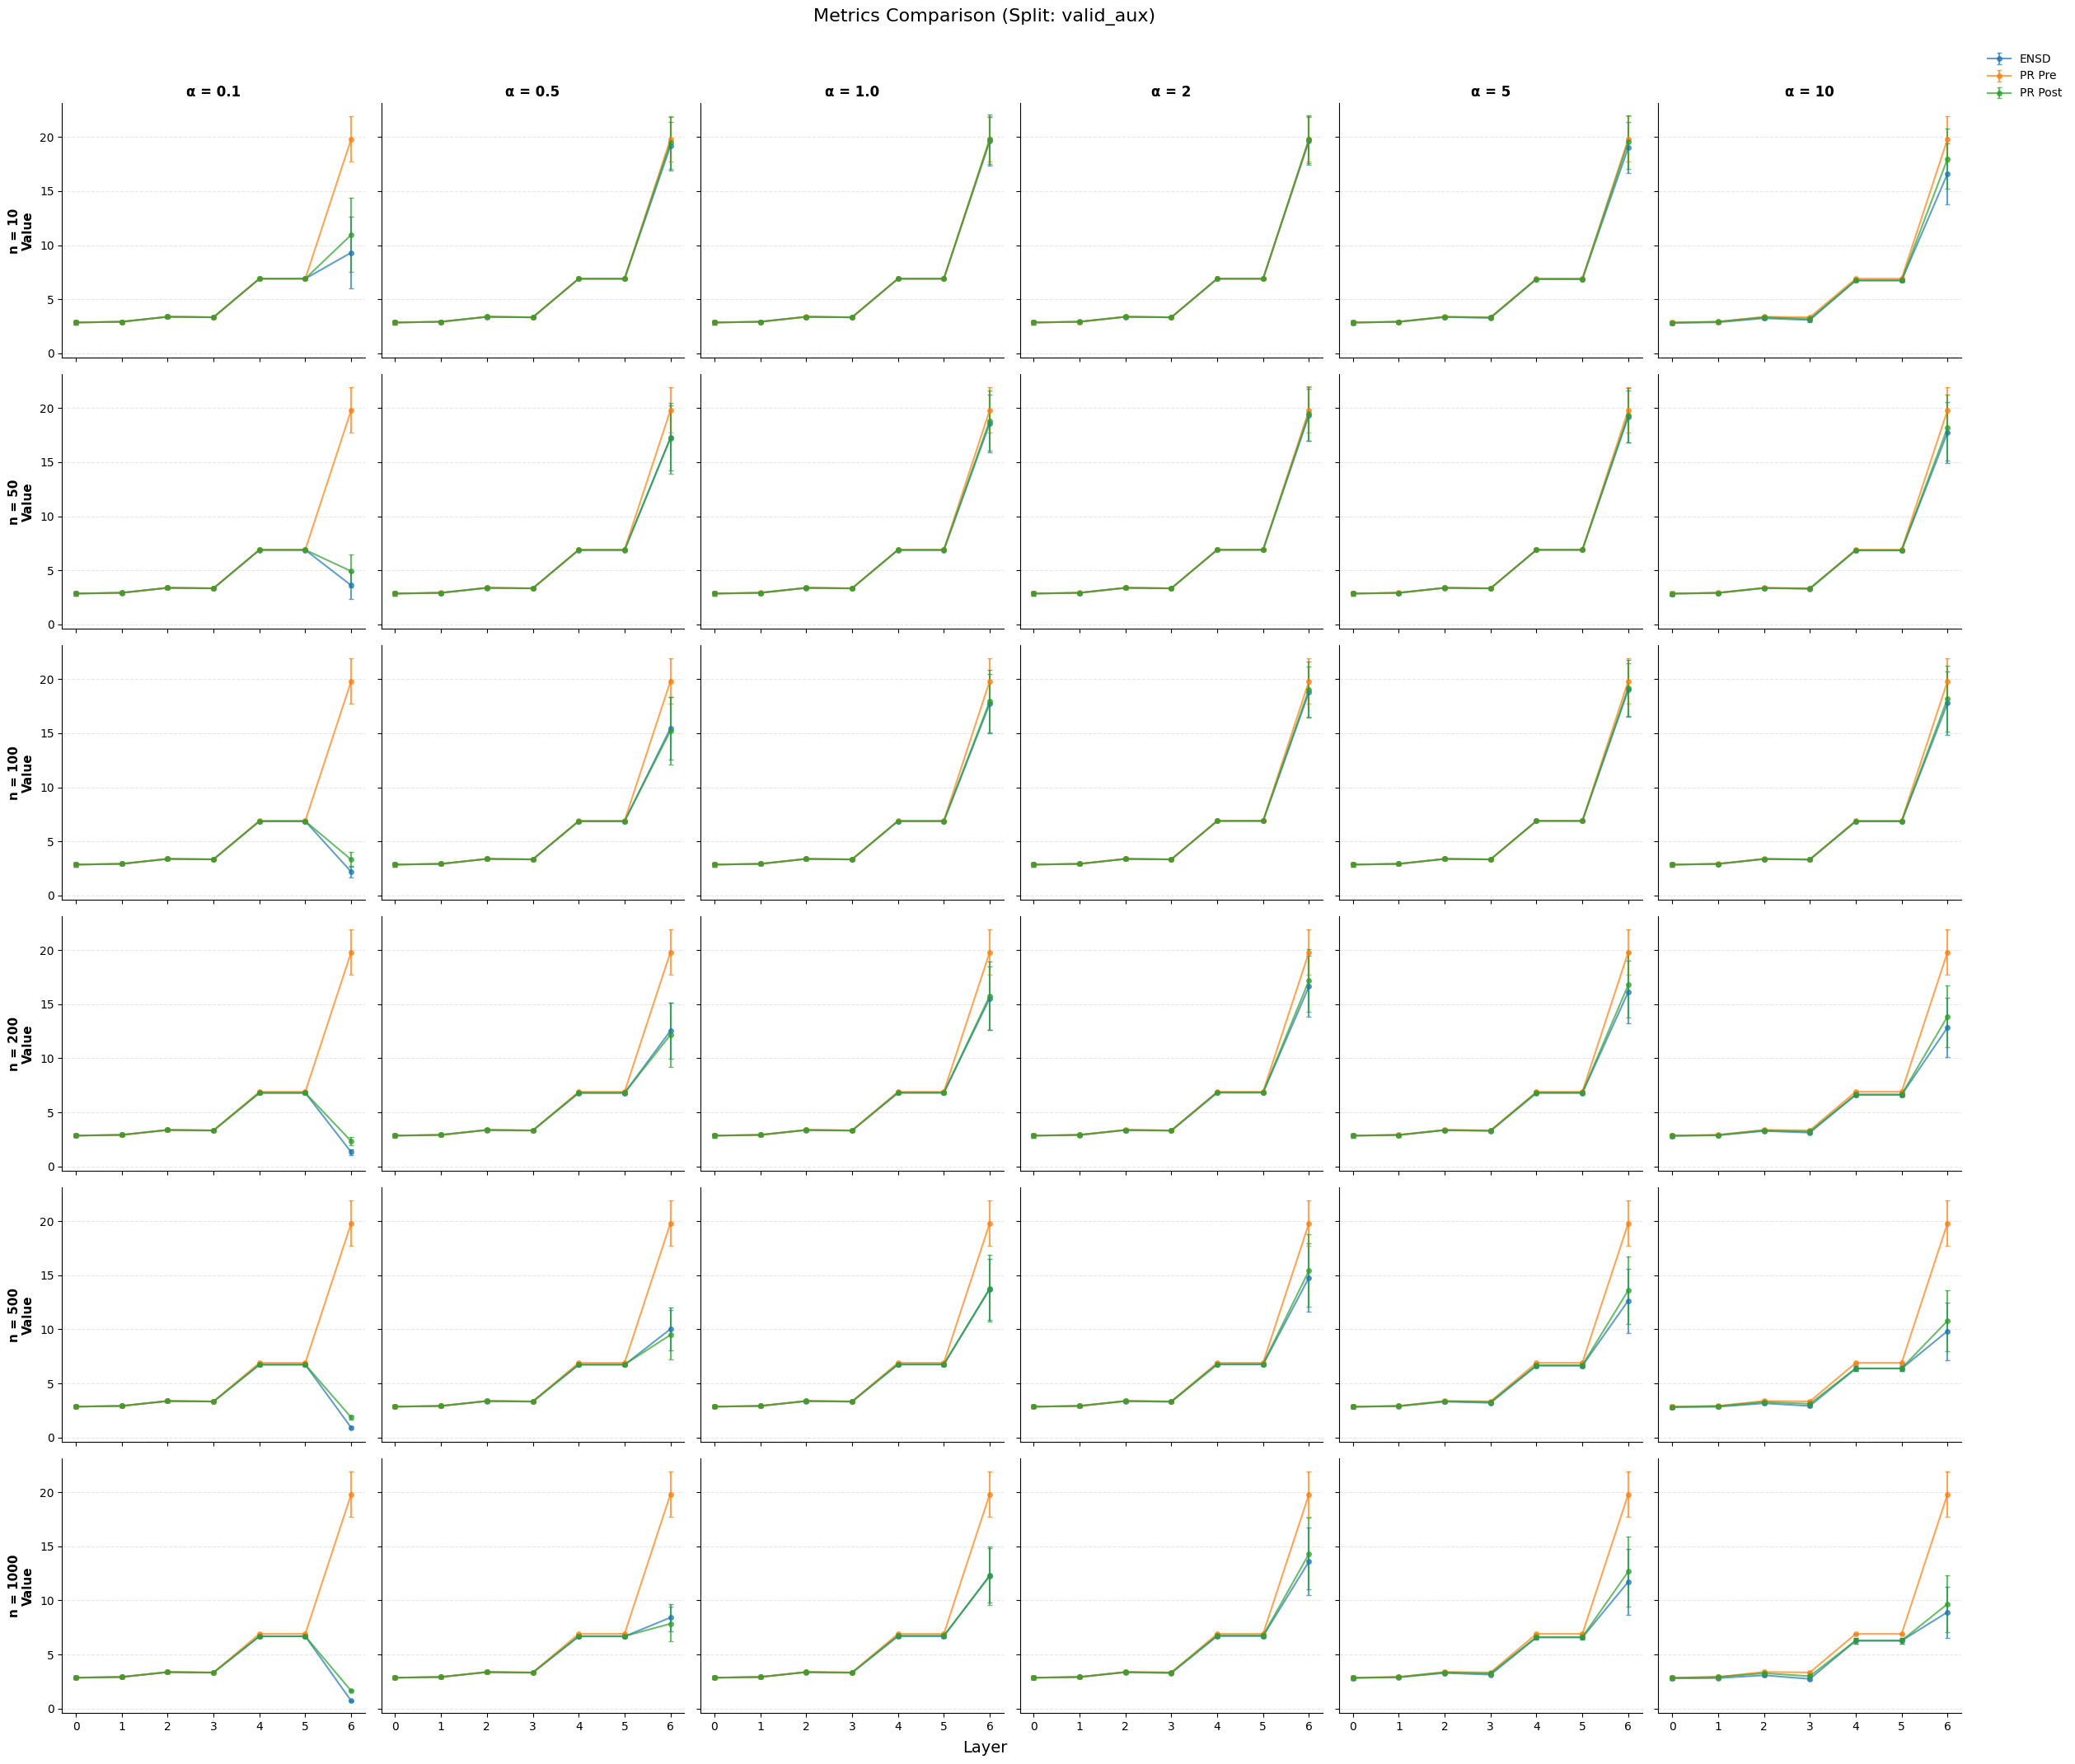

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=[100],
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    """
    Creates a single large figure grid.
    Rows = n_samples
    Cols = alphas
    """
    num_samples = len(n_samples)
    num_alphas = len(alphas)

    # Create the grid
    fig, axes = plt.subplots(
        num_samples, num_alphas, 
        figsize=(4 * num_alphas, 3.5 * num_samples),
        sharex=True, 
        sharey=True,
        squeeze=False # Ensures axes is always a 2D array [row, col]
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]
            
            # Data retrieval
            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            
            if not df_list:
                ax.set_title(f"n={n_sample}, α={alpha} (No Data)", fontsize=10)
                continue

            rows = []
            for df in df_list:
                d = df.copy()
                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]
                if split_name is not None:
                    found_col = next((c for c in split_col if c in d.columns), None)
                    if found_col is not None:
                        d = d[d[found_col] == split_name]
                
                # Filter specifically for your 3 variables
                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)
            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # Plotting
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"], sub["mean"], yerr=sub["std"].fillna(0),
                    marker="o", markersize=4, label=var, linewidth=1.5, capsize=2, alpha=0.7
                )

            # Labels and Styling
            if row_idx == 0:
                ax.set_title(f"α = {alpha}", fontsize=12, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontsize=11, fontweight='bold')
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    # Global labels
    fig.supxlabel("Layer", fontsize=14)
    fig.suptitle(f"Metrics Comparison (Split: {split_name})", fontsize=16, y=1.02)
    
    # Single legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.05, 1), frameon=False)

    plt.tight_layout()
    plt.show()

# Execution
plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[10, 50, 100, 200, 500, 1000],
    alphas=[ .1, 0.5, 1.0, 2, 5, 10],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"]
)

In [12]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.1,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_scaled_2/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--alpha_load={alpha}--n_samples={n_sample}--model=resnet"
            )
            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

Missing directory: random_seed=0--alpha_load=0.1--n_samples=10--model=resnet
Missing directory: random_seed=0--alpha_load=0.1--n_samples=20--model=resnet
Missing directory: random_seed=0--alpha_load=0.1--n_samples=50--model=resnet
Missing directory: random_seed=0--alpha_load=0.1--n_samples=100--model=resnet
Missing directory: random_seed=0--alpha_load=0.1--n_samples=200--model=resnet
Missing directory: random_seed=0--alpha_load=0.1--n_samples=500--model=resnet
Missing directory: random_seed=0--alpha_load=0.1--n_samples=1000--model=resnet
Missing directory: random_seed=1--alpha_load=0.1--n_samples=10--model=resnet
Missing directory: random_seed=1--alpha_load=0.1--n_samples=20--model=resnet
Missing directory: random_seed=1--alpha_load=0.1--n_samples=50--model=resnet
Missing directory: random_seed=1--alpha_load=0.1--n_samples=100--model=resnet
Missing directory: random_seed=1--alpha_load=0.1--n_samples=200--model=resnet
Missing directory: random_seed=1--alpha_load=0.1--n_samples=500--mode

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err

def plot_merged_run_and_csv(
    run_data,
    metric_name,          # key in run_data
    type_val,             # e.g. "train" or "valid" inside dict
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",      # "std" or "se"
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # separate color palettes to make both sources visible
    run_cmap = plt.colormaps["tab10"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab10")
    csv_cmap = plt.colormaps["tab20"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab20")

    # --------- RUN_DATA PLOT (alpha curves) ----------
    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    for i, alpha in enumerate(alphas):
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y
                    vals.append(y)
                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type=error_type)
                means.append(m)
                errs.append(e)

        # If everything is NaN, nothing will appear
        if np.all(np.isnan(means)):
            print(f"[WARN] run_data: α={alpha} produced all-NaN (likely key mismatch / missing data). Skipping.")
            continue

        ax.errorbar(
            samples, means, yerr=errs,
            label=f"c_pt={alpha}",
            color=run_cmap(i % 10),
            linestyle="-",
            marker="o",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,  # on top
        )


    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    errlab = "Std. Error" if error_type == "se" else "Std. Dev."
   # ax.set_title(f" (error bars = {errlab})", fontsize=14, pad=12)
    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("1 - Accuracy", fontsize=11)

    ax.legend(frameon=False, loc="best")
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
    

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[WARN] run_data: α=0.1 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=0.5 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=1.0 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=2 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=5 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=10 produced all-NaN (likely key mismatch / missing data). Skipping.


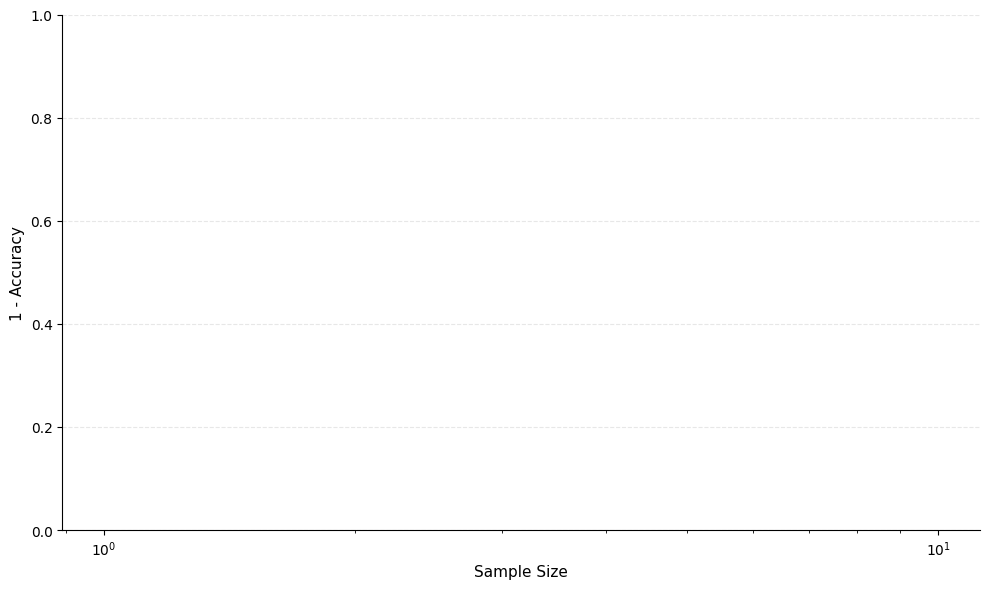

In [ ]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[WARN] run_data: α=0.1 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=0.5 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=1.0 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=2 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=5 produced all-NaN (likely key mismatch / missing data). Skipping.
[WARN] run_data: α=10 produced all-NaN (likely key mismatch / missing data). Skipping.


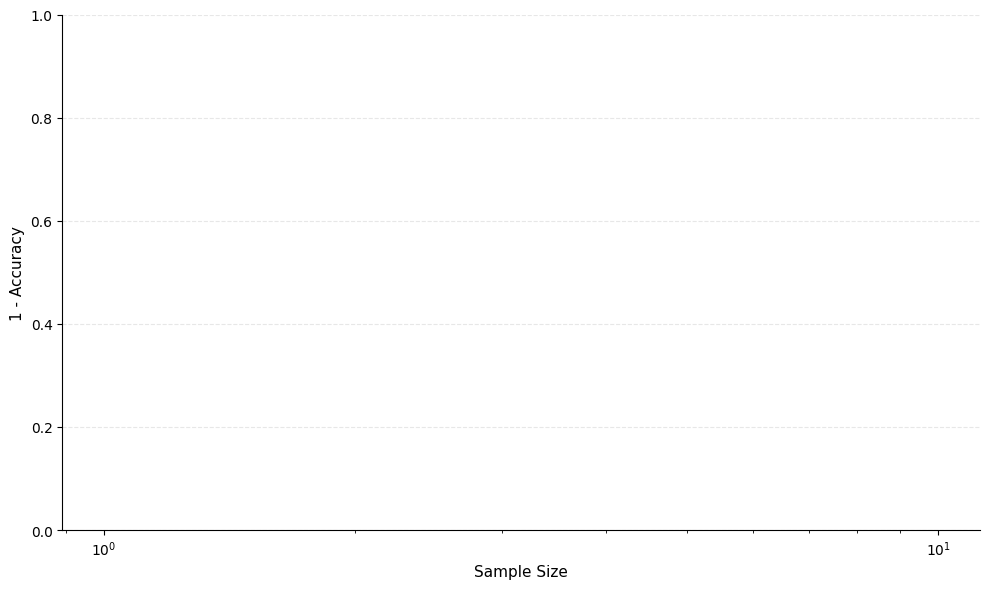

In [15]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=list(range(23)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err


def plot_merged_run_and_csv(
    run_data,
    metric_name,
    type_val,
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # ---- colormap with LOG-scaled alpha ----
    cmap = plt.colormaps["viridis"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("viridis")
    norm = LogNorm(vmin=min(alphas), vmax=max(alphas))

    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    # --------- RUN_DATA PLOT ----------
    for alpha in alphas:
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y

                    # protect log plots
                    if y <= 0:
                        continue

                    vals.append(y)

                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            print(f"[WARN] α={alpha} produced all-NaN. Skipping.")
            continue

        ax.errorbar(
            samples,
            means,
            yerr=errs,
            label=f"c_pt={alpha}",
            color=cmap(norm(alpha)),
            marker="o",
            linestyle="-",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("1 − Accuracy", fontsize=11)

    ax.legend(frameon=False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    # --------- Log-scaled colorbar ----------
    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    # cbar.set_label("c_pt (alpha)", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[WARN] α=0.1 produced all-NaN. Skipping.
[WARN] α=0.5 produced all-NaN. Skipping.
[WARN] α=1.0 produced all-NaN. Skipping.
[WARN] α=2 produced all-NaN. Skipping.
[WARN] α=5 produced all-NaN. Skipping.
[WARN] α=10 produced all-NaN. Skipping.


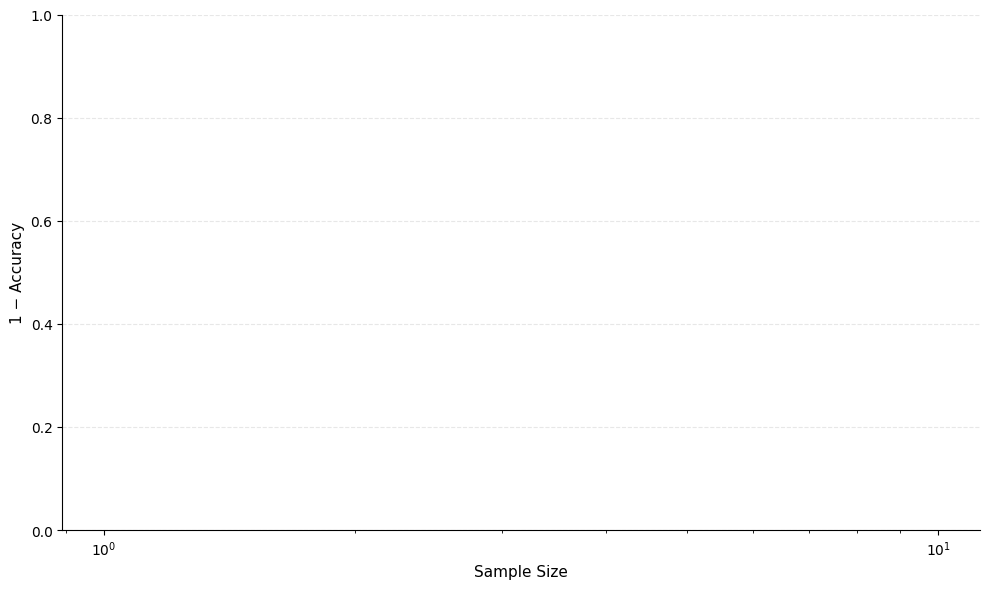

In [17]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=list(range(23)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")